In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sentiment_df = pd.read_csv("./csv_files/fear_greed_index.csv")
trades_df = pd.read_csv("./csv_files/historical_data.csv")

In [23]:
print(sentiment_df.head())


    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [26]:
df = trades_df.copy()

# Rename columns for convenience (optional but clean)
df = df.rename(columns={
    'Execution Price': 'execution_price',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Timestamp IST': 'timestamp',
    'Closed PnL': 'closed_pnl'
})

# Convert datatypes
df['execution_price'] = pd.to_numeric(df['execution_price'], errors='coerce')
df['size_usd'] = pd.to_numeric(df['size_usd'], errors='coerce')
df['closed_pnl'] = pd.to_numeric(df['closed_pnl'], errors='coerce')

# Robust timestamp parsing (handles mixed formats)
df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Create date column
df['date'] = df['timestamp'].dt.date
df['date'] = pd.to_datetime(df['date'])
# Drop invalid rows
df = df.dropna(subset=['date', 'size_usd', 'closed_pnl'])

print("Cleaned shape:", df.shape)

Cleaned shape: (211224, 17)


In [27]:
# Win / loss flag
df['is_win'] = (df['closed_pnl'] > 0).astype(int)

# Absolute volume
df['volume_usd'] = df['size_usd'].abs()

# Direction normalization
df['direction'] = df['side'].str.lower().map({
    'buy': 'long',
    'sell': 'short'
})

df.head()

,Account,Coin,execution_price,Size Tokens,size_usd,side,timestamp,Start Position,Direction,closed_pnl,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,is_win,volume_usd,direction
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,0,7872.16,long
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,0,127.68,long
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,0,1150.63,long
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,0,1142.04,long
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,0,69.75,long


In [28]:
daily_metrics = df.groupby('date').agg(
    total_pnl=('closed_pnl', 'sum'),
    avg_pnl=('closed_pnl', 'mean'),
    trade_count=('closed_pnl', 'count'),
    total_volume_usd=('volume_usd', 'sum'),
    win_rate=('is_win', 'mean')
).reset_index()

daily_metrics.head()

,date,total_pnl,avg_pnl,trade_count,total_volume_usd,win_rate
0,2023-05-01,0.000000,0.000000,3,477.00,0.000000
1,2023-12-05,0.000000,0.000000,9,50005.83,0.000000
2,2023-12-14,-205.434737,-18.675885,11,113203.35,0.363636
3,2023-12-15,-24.632034,-12.316017,2,10609.95,0.000000
4,2023-12-16,0.000000,0.000000,3,15348.77,0.000000


In [29]:
directional = (
    df.groupby(['date', 'direction'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

directional['long_short_ratio'] = (
    directional.get('long', 0) /
    (directional.get('short', 1))
)

directional.head()

direction,date,long,short,long_short_ratio
0,2023-05-01,3,0,inf
1,2023-12-05,7,2,3.500000
2,2023-12-14,5,6,0.833333
3,2023-12-15,2,0,inf
4,2023-12-16,3,0,inf


In [30]:
daily_metrics = daily_metrics.merge(
    directional[['date', 'long_short_ratio']],
    on='date',
    how='left'
)

daily_metrics.head()

,date,total_pnl,avg_pnl,trade_count,total_volume_usd,win_rate,long_short_ratio
0,2023-05-01,0.000000,0.000000,3,477.00,0.000000,inf
1,2023-12-05,0.000000,0.000000,9,50005.83,0.000000,3.500000
2,2023-12-14,-205.434737,-18.675885,11,113203.35,0.363636,0.833333
3,2023-12-15,-24.632034,-12.316017,2,10609.95,0.000000,inf
4,2023-12-16,0.000000,0.000000,3,15348.77,0.000000,inf


In [ ]:
daily_metrics.to_csv(
    "./csv_files/daily_trader_metrics.csv",
    index=False
)

print("Saved csv_files/daily_trader_metrics.csv")

Saved csv_files/daily_trader_metrics.csv


In [34]:
sentiment = sentiment_df.copy()

# Ensure date is datetime
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Normalize classification text
sentiment['classification'] = sentiment['classification'].str.lower()

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,fear,2018-02-01
1,1517549400,15,extreme fear,2018-02-02
2,1517635800,40,fear,2018-02-03
3,1517722200,24,extreme fear,2018-02-04
4,1517808600,11,extreme fear,2018-02-05


In [35]:
def map_sentiment(x):
    if 'fear' in x:
        return 'fear'
    elif 'greed' in x:
        return 'greed'
    else:
        return 'neutral'

sentiment['sentiment_group'] = sentiment['classification'].apply(map_sentiment)

sentiment['sentiment_group'].value_counts()

,count
sentiment_group,
fear,1289
greed,959
neutral,396


In [36]:
merged_df = daily_metrics.merge(
    sentiment[['date', 'sentiment_group', 'value']],
    on='date',
    how='inner'
)

merged_df.head()

,date,total_pnl,avg_pnl,trade_count,total_volume_usd,win_rate,long_short_ratio,sentiment_group,value
0,2023-05-01,0.000000,0.000000,3,477.00,0.000000,inf,greed,63
1,2023-12-05,0.000000,0.000000,9,50005.83,0.000000,3.500000,greed,75
2,2023-12-14,-205.434737,-18.675885,11,113203.35,0.363636,0.833333,greed,72
3,2023-12-15,-24.632034,-12.316017,2,10609.95,0.000000,inf,greed,70
4,2023-12-16,0.000000,0.000000,3,15348.77,0.000000,inf,greed,67


In [37]:
print("Merged shape:", merged_df.shape)
print(merged_df['sentiment_group'].value_counts())

Merged shape: (479, 9)
sentiment_group
greed      307
fear       105
neutral     67
Name: count, dtype: int64


In [ ]:
import os
os.makedirs("csv_files", exist_ok=True)

merged_df.to_csv(
    "./csv_files/merged_data.csv",
    index=False
)

print(" Saved csv_files/merged_data.csv")


 Saved csv_files/merged_data.csv


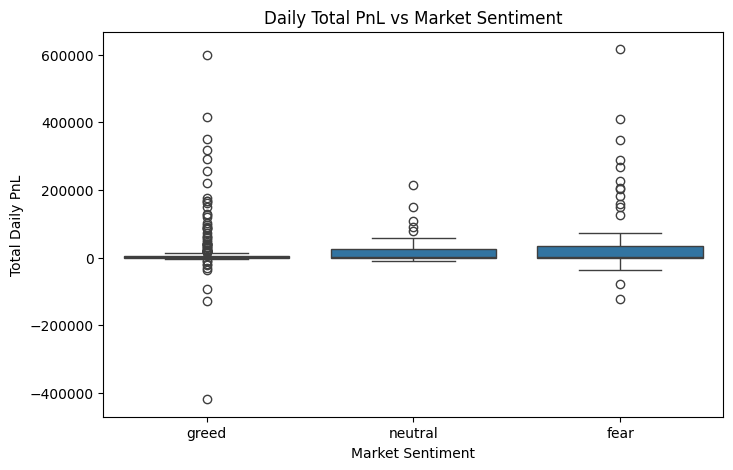

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=merged_df,
    x='sentiment_group',
    y='total_pnl'
)

plt.title("Daily Total PnL vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Daily PnL")

plt.savefig("./outputs/pnl_vs_sentiment.png", dpi=120)
plt.show()

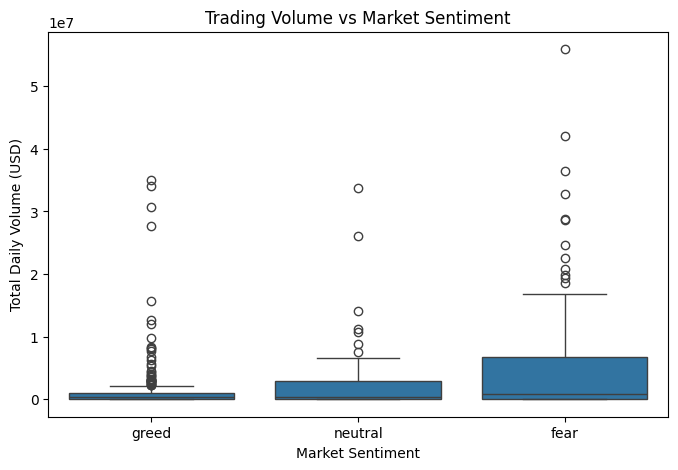

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=merged_df,
    x='sentiment_group',
    y='total_volume_usd'
)

plt.title("Trading Volume vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Daily Volume (USD)")

plt.savefig("./outputs/volume_fear_greed.png", dpi=120)
plt.show()

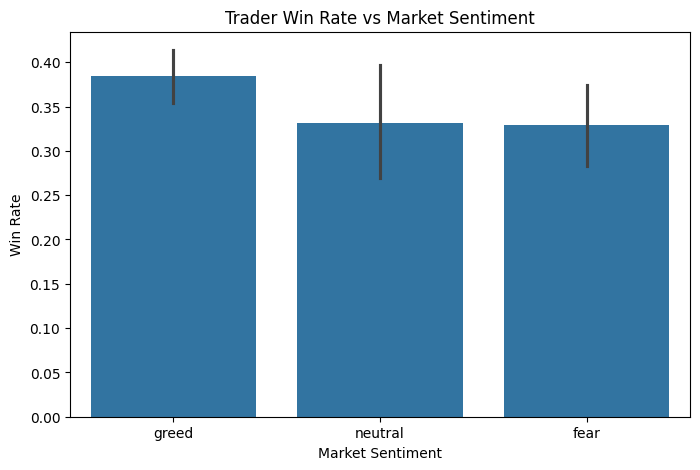

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=merged_df,
    x='sentiment_group',
    y='win_rate'
)

plt.title("Trader Win Rate vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")

plt.savefig("./outputs/winrate_sentiment.png", dpi=120)
plt.show()


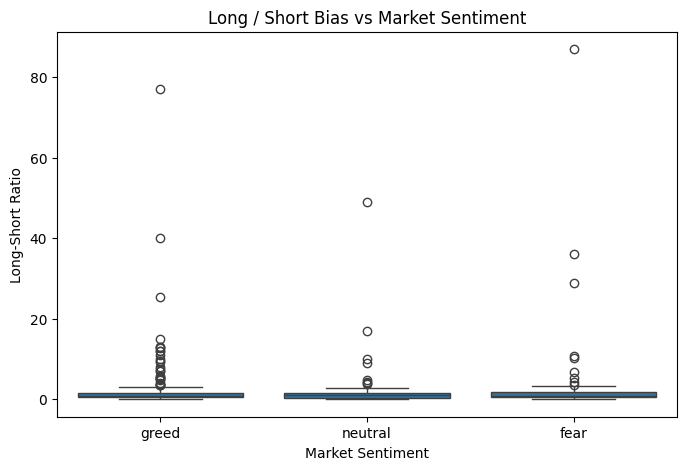

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=merged_df,
    x='sentiment_group',
    y='long_short_ratio'
)

plt.title("Long / Short Bias vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Long-Short Ratio")

plt.savefig("./outputs/long_short_ratio.png", dpi=120)
plt.show()

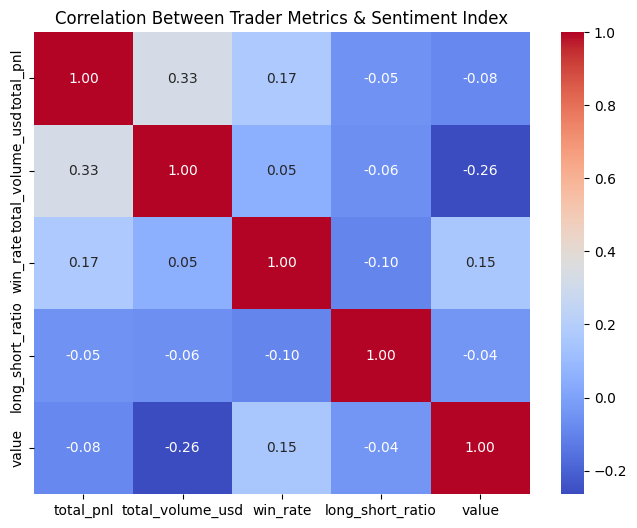

In [ ]:
plt.figure(figsize=(8, 6))

corr = merged_df[
    ['total_pnl', 'total_volume_usd', 'win_rate', 'long_short_ratio', 'value']
].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Trader Metrics & Sentiment Index")

plt.savefig("./outputs/correlation_heatmap.png", dpi=120)
plt.show()
